# Stage 4: Feature Engineering - Feature Creation
**Member:** **M4 — IT25102357**
**Assigned Preprocessing Technique:** Domain-driven feature creation (wage compliance, employer and education features)
**Dataset:** [US Permanent Visa Applications](https://www.kaggle.com/datasets/jboysen/us-perm-visas) (US Department of Labor, via Kaggle)
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Pipeline Position:** Stage 4 of 6 (sequential)
**Input:** `results/outputs/stage3_outliers_treated.parquet`
**Output:** `results/outputs/stage4_features_created.parquet`

---
## 1. Explanation of the Technique

Feature creation turns raw attributes into variables that express the *mechanism* behind the outcome - ratios, differences, comparisons and flags. A well-chosen feature can make a non-linear relationship linear (helping simple models) and makes the model easier to explain.

---
## 2. Justification for THIS Dataset Specifically

PERM labor certification is granted only if hiring the foreign worker does not undercut US workers. In particular the employer must offer **at least the prevailing wage** for the occupation and area. That rule motivates the main features:

| Feature | Definition | Rationale |
|---|---|---|
| `wage_to_pw_ratio` | offered / prevailing wage, clipped to [0, 5] | Direct measure of wage compliance |
| `wage_below_pw` | 1 if ratio < 1 | Rule violation flag |
| `wage_gap_annual` | offered - prevailing (USD/yr) | Absolute margin above the floor |
| `employer_age` | 2016 - founding year | Established employers vs new / shell companies |
| `has_agent` | attorney / agent firm listed | Professional preparation of the application |
| `same_state` | worksite state = employer state | Remote placements (e.g. consulting) are scrutinised more |
| `edu_meets_requirement` | worker education >= required education | Worker qualifies for the job as advertised |
| `edu_gap` | worker - required education level | Over / under-qualification |

All features use only information on the application at filing time - no decision dates or outcomes.

### Why this must be Stage 4
- After Stage 3, so ratios are built from capped wages (no division by mis-scaled hourly values).
- Before Stage 5, so the new continuous features are standardised together with the originals.

In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

# --- Project paths: search upward for the folder that contains data/raw ---
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)

RAW_CSV = os.path.join(ROOT, 'data', 'raw', 'us_perm_visas.csv')
EXT_DIR = os.path.join(ROOT, 'data', 'external')
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
PLOT_DIR = os.path.join(ROOT, 'results', 'eda_visualizations')
LOG_DIR = os.path.join(ROOT, 'results', 'logs')
for _d in (OUT_DIR, PLOT_DIR, LOG_DIR):
    os.makedirs(_d, exist_ok=True)

# --- Shared settings (identical in every notebook) ---
TARGET = 'denied'            # 1 = Denied, 0 = Certified / Certified-Expired
SEED = 42
TEST_SIZE = 0.20             # stratified 80/20 split; teammates use 5-fold CV on the train rows
DEV_SAMPLE = None            # e.g. 0.10 for a fast ~35k-row run; None = full dataset
EDA_ONLY_COLS = ['case_status', 'decision_date']                          # kept for EDA, dropped in S6
LEAKAGE_COLS = ['case_id', 'case_received_date', 'application_type', 'processing_days']  # must never reach a model
NON_FEATURE_COLS = EDA_ONLY_COLS + [TARGET, 'split']

REFERENCE_YEAR = 2016                                                     # last year in the dataset
S4_PASSTHROUGH = ['employer_state', 'job_info_work_state', 'agent_firm_name']  # raw columns kept by S2 for S4
SCALE_COLS = ['wage_offer_annual', 'pw_annual', 'wage_gap_annual', 'wage_to_pw_ratio',  # continuous / ordinal
              'employer_num_employees_log', 'employer_filing_count_log', 'employer_yr_estab', 'employer_age',
              'pw_level', 'edu_worker', 'edu_required', 'edu_gap']

# --- Reference tables (data/external) ---
_states = pd.read_csv(os.path.join(EXT_DIR, 'us_states.csv'))
STATE_LOOKUP = {**dict(zip(_states['state_name'], _states['state_code'])),
                **dict(zip(_states['state_code'], _states['state_code']))}
STATE_REGION = dict(zip(_states['state_code'], _states['census_region']))
VALID_SOC = set(pd.read_csv(os.path.join(EXT_DIR, 'soc_major_groups.csv'), dtype=str)['soc_major_group'])
_naics = pd.read_csv(os.path.join(EXT_DIR, 'naics_sectors.csv'), dtype=str)
VALID_NAICS = set(_naics['naics_2digit'])
NAICS_SECTOR_KEY = dict(zip(_naics['naics_2digit'], _naics['sector_key']))

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
print(f'Project root: {ROOT}')

Project root: /Users/jathushansundararasu/Desktop/us_prem_visa


In [2]:
# ==============================================================================
# STAGE 4: Feature Engineering - Creation (M4)
# ==============================================================================
NEW_FEATURES = ['wage_to_pw_ratio', 'wage_below_pw', 'wage_gap_annual', 'employer_age', 'has_agent',
                'same_state', 'edu_meets_requirement', 'edu_gap']


def stage4_feature_engineering(df, plot_dir=PLOT_DIR, show_plot=False):
    """
    Domain features (all available when the application is filed):
    - wage_to_pw_ratio / wage_below_pw / wage_gap_annual: PERM requires the offer to be >= the prevailing wage.
    - employer_age: 2016 - founding year.
    - has_agent: application filed through an attorney / agent firm.
    - same_state: worksite in the employer's home state.
    - edu_meets_requirement / edu_gap: worker education vs the job's required education.
    """
    d = df.copy()
    d['wage_to_pw_ratio'] = (d['wage_offer_annual'] / d['pw_annual'].clip(lower=1)).clip(0, 5).astype('float32')
    d['wage_below_pw'] = (d['wage_to_pw_ratio'] < 1).astype('int8')
    d['wage_gap_annual'] = (d['wage_offer_annual'] - d['pw_annual']).astype('float32')
    d['employer_age'] = (REFERENCE_YEAR - d['employer_yr_estab']).clip(lower=0).astype('float32')
    d['has_agent'] = d['agent_firm_name'].ne('Unknown').astype('int8')
    d['same_state'] = (d['employer_state'].eq(d['job_info_work_state']) & d['employer_state'].ne('Unknown')).astype('int8')
    known = (d['edu_worker'] > 0) & (d['edu_required'] > 0)
    d['edu_meets_requirement'] = (known & (d['edu_worker'] >= d['edu_required'])).astype('int8')
    d['edu_gap'] = np.where(known, d['edu_worker'] - d['edu_required'], 0).astype('int8')
    d = d.drop(columns=S4_PASSTHROUGH)

    if plot_dir:
        t = d[d['split'].eq('train')]
        fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
        plt.subplots_adjust(wspace=0.25)
        bins = [0, 0.95, 0.999, 1.05, 1.15, 1.3, 1.6, 5.01]
        labels = ['<0.95', '0.95-1.0', '1.0-1.05', '1.05-1.15', '1.15-1.3', '1.3-1.6', '>1.6']
        grp = t.groupby(pd.cut(t['wage_to_pw_ratio'], bins=bins, labels=labels, include_lowest=True), observed=False)[TARGET]
        rate, n = grp.mean() * 100, grp.size()
        axes[0].plot(labels, rate.values, marker='o', linewidth=2.5, color='#8e44ad')
        for i, (r, k) in enumerate(zip(rate.values, n.values)):
            axes[0].annotate(f'{r:.1f}%\n(n={k:,})', (i, r), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
        axes[0].set_title('Denial rate vs offered / prevailing wage ratio', fontweight='bold')
        axes[0].set_xlabel('wage_to_pw_ratio')
        axes[0].set_ylabel('Denied (%)')
        axes[0].set_ylim(0, np.nanmax(rate.values) * 1.35)

        flags = ['has_agent', 'same_state', 'edu_meets_requirement', 'wage_below_pw']
        r0 = [t.loc[t[f] == 0, TARGET].mean() * 100 for f in flags]
        r1 = [t.loc[t[f] == 1, TARGET].mean() * 100 for f in flags]
        x = np.arange(len(flags))
        b0 = axes[1].bar(x - 0.2, r0, 0.4, label='flag = 0', color='#95a5a6')
        b1 = axes[1].bar(x + 0.2, r1, 0.4, label='flag = 1', color='#e67e22')
        axes[1].bar_label(b0, fmt='%.1f%%', fontsize=8, padding=2)
        axes[1].bar_label(b1, fmt='%.1f%%', fontsize=8, padding=2)
        axes[1].set_xticks(x, [f.replace('_', '_\n', 1) for f in flags])
        axes[1].set_ylabel('Denied (%)')
        axes[1].set_title('Denial rate for the new binary features', fontweight='bold')
        axes[1].legend()
        axes[1].margins(y=0.15)
        plt.suptitle('m4: Feature engineering - signal of the created features (train rows)', fontsize=14, fontweight='bold', y=1.03)
        plt.savefig(f'{plot_dir}/m4_engineered_feature_signal.png', dpi=200, bbox_inches='tight')
        plt.show() if show_plot else plt.close()
    print(f'[Stage 4] created {len(NEW_FEATURES)} features: {NEW_FEATURES}')
    return d

Loaded Stage 3 data: 354,849 rows x 106 columns


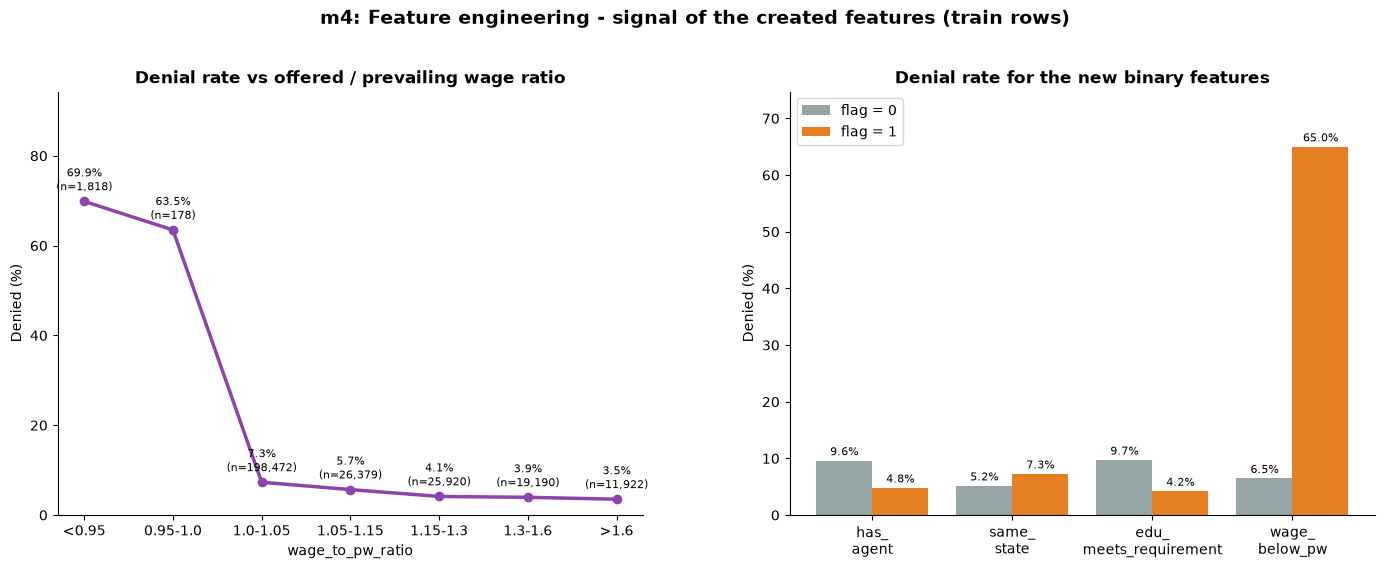

[Stage 4] created 8 features: ['wage_to_pw_ratio', 'wage_below_pw', 'wage_gap_annual', 'employer_age', 'has_agent', 'same_state', 'edu_meets_requirement', 'edu_gap']


Saved Stage 4 output: 354,849 rows x 111 columns


,count,mean,std,min,25%,50%,75%,max
wage_to_pw_ratio,354849.0,1.108,0.311,0.09,1.0,1.0,1.091,5.0
wage_below_pw,354849.0,0.008,0.087,0.00,0.0,0.0,0.000,1.0
wage_gap_annual,354849.0,7891.902,19195.266,-170330.00,0.0,0.0,7605.000,208152.0
employer_age,354849.0,27.142,27.223,3.00,17.0,20.0,23.000,163.0
has_agent,354849.0,0.558,0.497,0.00,0.0,1.0,1.000,1.0
same_state,354849.0,0.834,0.372,0.00,1.0,1.0,1.000,1.0
edu_meets_requirement,354849.0,0.507,0.500,0.00,0.0,1.0,1.000,1.0
edu_gap,354849.0,0.025,0.359,-3.00,0.0,0.0,0.000,3.0


In [3]:
# 1. Load Stage 3 output and create features (+ EDA plot m4)
df_3 = pd.read_parquet(os.path.join(OUT_DIR, 'stage3_outliers_treated.parquet'))
print(f'Loaded Stage 3 data: {df_3.shape[0]:,} rows x {df_3.shape[1]} columns')
df_4 = stage4_feature_engineering(df_3, show_plot=True)
df_4.to_parquet(os.path.join(OUT_DIR, 'stage4_features_created.parquet'), index=False)
print(f'Saved Stage 4 output: {df_4.shape[0]:,} rows x {df_4.shape[1]} columns')
df_4[NEW_FEATURES].describe().T.round(3)

In [4]:
# 2. Verification ("done when" checks)
assert all(c in df_4.columns for c in NEW_FEATURES)
assert not set(S4_PASSTHROUGH) & set(df_4.columns), 'passthrough columns should be dropped'
assert np.isfinite(df_4[NEW_FEATURES].to_numpy(dtype=float)).all(), 'inf / NaN in new features'
print(f'{len(NEW_FEATURES)} new features, no inf / NaN. All Stage 4 checks passed.')

8 new features, no inf / NaN. All Stage 4 checks passed.


## 3. EDA Interpretation & Findings

1. **The wage rule is the strongest single signal in the dataset.** Applications offering less than 95% of the prevailing wage are denied **69.9%** of the time (n = 1,818); 95-100% -> 63.5%; at or above the prevailing wage the rate collapses to 7.3% and keeps falling to 3.5% for offers > 1.6x. `wage_below_pw = 1` means a **65.0%** denial rate vs 6.5%.
2. **Education fit:** when the worker meets the required education the denial rate is 4.2% vs 9.7% otherwise.
3. **Professional preparation:** applications filed through an agent / attorney are denied about half as often (4.8% vs 9.6%).
4. **Caveat for the report:** `has_agent` and the education fields are partly missing for the same older form version, so they are correlated (~0.7, see Stage 6 heatmap); part of their signal reflects the form version / year rather than the applicant.